# DATA CLEANING & HANDLING

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df['Release_Date'] = df['Release_Date'].dt.year

columns = ['Overview','Poster_Url']
df.drop(columns, axis=1, inplace=True)

def categorize_col(df,col,labels):
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]

    df[col] = pd.cut(df[col],edges, labels = labels, duplicates='drop')
    return df

labels = ['Not_Popular','Below_Avg','Avg','Popular']

categorize_col(df,'Vote_Average',labels)

df.dropna(inplace=True)

df.head(10)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_Avg,en,Thriller
3,2021,Encanto,2402.201,5076,Popular,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Avg,en,"Action, Adventure, Thriller, War"
5,2022,The Commando,1750.484,33,Avg,en,"Action, Crime, Thriller"
6,2022,Scream,1675.161,821,Avg,en,"Horror, Mystery, Thriller"
7,2022,Kimi,1601.782,206,Below_Avg,en,Thriller
8,2022,Fistful of Vengeance,1594.013,114,Not_Popular,en,"Action, Crime, Fantasy"
9,2021,Eternals,1537.406,4726,Popular,en,Science Fiction


# DATA VISUALIZATION

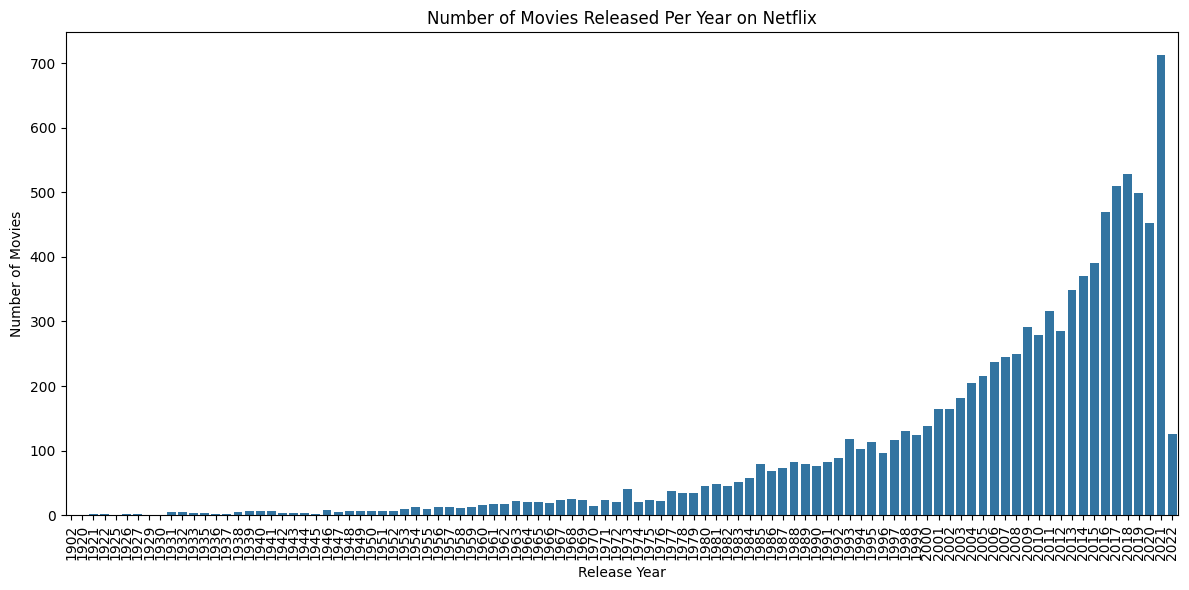

In [2]:
# Trend Over Years: Titles Released Per Year...

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Release_Date', order=sorted(df['Release_Date'].dropna().unique()))
plt.xticks(rotation=90)
plt.title('Number of Movies Released Per Year on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10796\2235909558.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


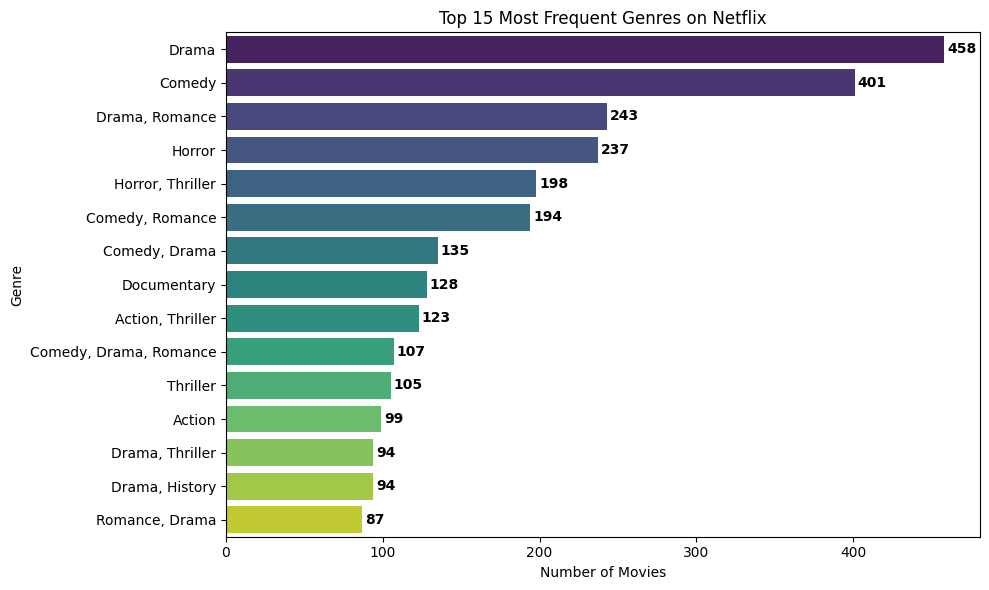

In [3]:
# Genre Popularity: Most Frequent Genre Released...

top_genres = df['Genre'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')

# Add labels on bars
for i, v in enumerate(top_genres.values):
    plt.text(v + 2, i, str(v), color='black', va='center', fontweight='bold')

plt.title('Top 15 Most Frequent Genres on Netflix')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [4]:
# Trending Genres: Genre of Trending Titles...

top_trending_genres = trending['Genre'].value_counts().head(10)

# Plot
plt.figure(figsize=(8, 8))
colors = sns.color_palette('coolwarm', len(top_trending_genres))

plt.pie(top_trending_genres.values, labels=top_trending_genres.index,
        autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops=dict(width=0.4))

plt.title('Top 10 Trending Genres (Donut Chart)')
plt.tight_layout()
plt.show()



NameError: name 'trending' is not defined

In [ ]:
# Flop/Unrated Titles by Genre...

top_flop_genres = flops['Genre'].value_counts().head(10)
genres = top_flop_genres.index
counts = top_flop_genres.values

plt.figure(figsize=(10, 6))
plt.hlines(y=genres, xmin=0, xmax=counts, color='salmon')
plt.plot(counts, genres, "o", color='darkred')

# Add labels
for i, v in enumerate(counts):
    plt.text(v + 1, i, str(v), va='center')

plt.title('Top 10 Flop/Unrated Genres (Lollipop Chart)')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()


In [ ]:
# Language Barrier: Most Widely Preferred Languages.

top_languages = df['Original_Language'].value_counts().head(10)
plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel', len(top_languages))

# Custom function to hide small labels
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 5 else ''

plt.pie(top_languages.values,
        labels=top_languages.index,
        autopct=autopct_format,
        startangle=140,
        colors=colors)

plt.title('Top 10 Languages Used in Netflix Movies (Pie Chart)')
plt.tight_layout()
plt.show()


